# La deforestación baja el umbral climático del Amazonas en 2 °C (según el modelo)

**1,5 °C era la meta climática del Acuerdo de París.** Un nuevo modelo del Amazonas dice que, con la deforestación que ya hay proyectada, ese mismo 1,5 °C basta para que **dos tercios del bosque** pierdan estabilidad. Sin deforestación, el umbral está en 3,7-4 °C.

Según el modelo, la deforestación sola baja el umbral crítico **dos grados Celsius**.

📄 **Paper:** Wunderling et al. (2026) · *Nature* · [10.1038/s41586-026-10456-0](https://doi.org/10.1038/s41586-026-10456-0)  
🎬 **Video corto:** [Ver en YouTube](https://youtube.com/shorts/LYnOSR6BYB0)  
▶ **Reproducir en Colab:** [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-amazon-deforestacion-umbral/notebook.ipynb)

## Qué hicieron

El equipo construyó un modelo dinámico del Amazonas (PyCascades) sobre una grilla de **416 celdas de 1° × 1°** que cubre toda la cuenca. Cada celda se simuló bajo **cuatro escenarios climáticos** (los SSPs estándar, de bajo a alto calentamiento) entre 1950 y 2099, con paso mensual.

El modelo no solo evalúa cada celda por separado: también traza cómo **el agua que evapora una zona del bosque viaja por la atmósfera** y cae como lluvia río arriba. Cuando una región se seca, deja de regar a las vecinas — y eso puede empujarlas a su propio umbral. La simulación corrió **1,25 millones de veces** (3.000 réplicas por celda × 10 ensembles — corridas paralelas con condiciones iniciales distintas) para mapear esos efectos en cascada.

Lo que encontraron: la deforestación que ya está proyectada cambia drásticamente cuándo el sistema colapsa.

**Importante:** esto es un modelo. El paper habla siempre en términos de *riesgo* y *proyección*, no de certeza. Aquí mantenemos ese mismo registro.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_PARIS = 1.5            # °C — meta del Acuerdo de París
UMBRAL_SIN_DEFOR = 3.85       # °C — punto medio del rango sin deforestación (3,7-4,0)
UMBRAL_CON_DEFOR = 1.7        # °C — punto medio del rango con deforestación (1,5-1,9)
FUENTE = ('Fuente: Wunderling et al. (2026), Nature 10.1038/s41586-026-10456-0 | '
          'Datos: Figs S2-S6 + Tabla 1 del paper')
COLOR_SIN_DEFOR = '#059669'   # Verde — escenario protegido
COLOR_CON_DEFOR = '#DC2626'   # Rojo — escenario BaU deforestación
COLOR_REFERENCIA = '#D97706'  # Ámbar — meta climática
COLOR_CONTEXTO = '#7C3AED'    # Violeta — variables secundarias

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Estilo CaM (local primero, fallback a GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga de los 6 datasets reconstruidos del paper + SI
ssp = pd.read_csv('datos/transition_2090s_por_ssp.csv')
headlines = pd.read_csv('datos/headline_thresholds.csv')
ssp_defor = pd.read_csv('datos/ssp_defor_2090.csv')
decadal_map = pd.read_csv('datos/decadal_map_only.csv')
decadal_mcwd = pd.read_csv('datos/decadal_mcwd_only.csv')
umbrales = pd.read_csv('datos/umbrales_criticos.csv')

print(f'Escenarios SSP cargados: {ssp.shape[0]}')
print(f'Calentamiento 2090s: {ssp["warming_2090s_C"].min()}-{ssp["warming_2090s_C"].max()} °C')
print(f'Décadas evaluadas (MAP): {decadal_map["decade"].nunique()} por SSP')
print(f'Variables de umbral hidrológico: {umbrales["variable"].tolist()}')

Escenarios SSP cargados: 4
Calentamiento 2090s: 1.8-4.9 °C
Décadas evaluadas (MAP): 8 por SSP
Variables de umbral hidrológico: ['MAP', 'MCWD']


## ¿Qué tan distinto es el destino del Amazonas con y sin deforestación?

Aquí está.

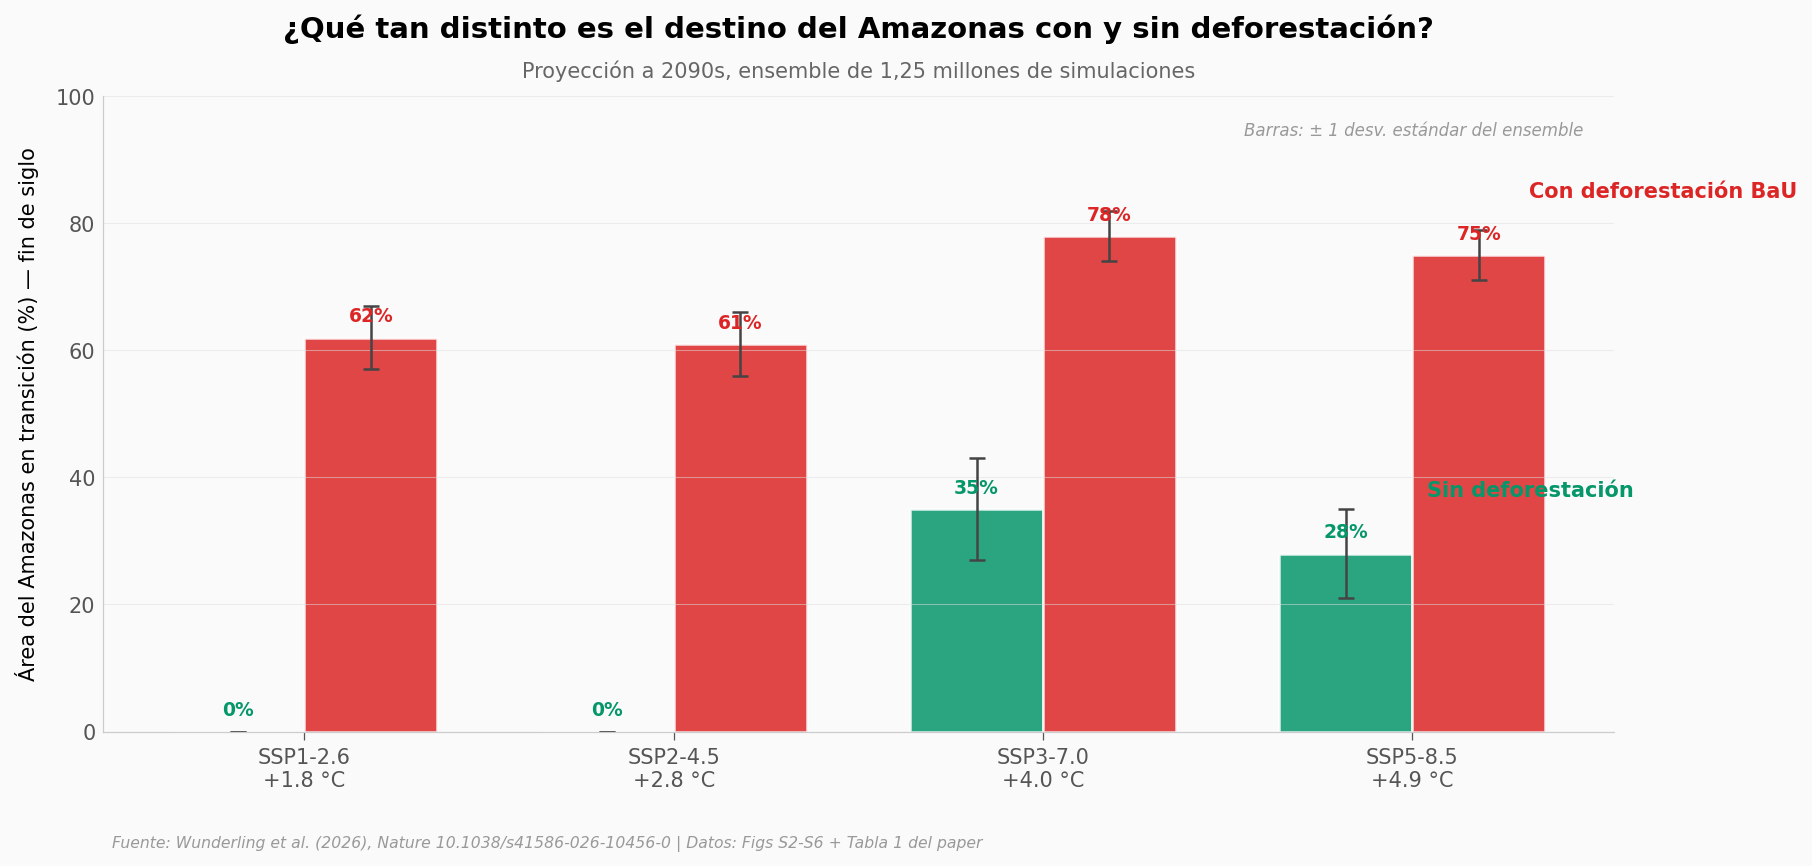

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = np.arange(len(ssp))
ancho = 0.36

barras_sin = ax.bar(x - ancho/2, ssp['transitioned_pct_sin_deforestacion'],
                    yerr=ssp['std_sin_deforestacion'], width=ancho,
                    color=COLOR_SIN_DEFOR, alpha=0.85,
                    edgecolor='white', linewidth=1.2,
                    error_kw=dict(ecolor='#444444', capsize=4, capthick=1.2, lw=1.2))
barras_con = ax.bar(x + ancho/2, ssp['transitioned_pct_con_deforestacion'],
                    yerr=ssp['std_con_deforestacion'], width=ancho,
                    color=COLOR_CON_DEFOR, alpha=0.85,
                    edgecolor='white', linewidth=1.2,
                    error_kw=dict(ecolor='#444444', capsize=4, capthick=1.2, lw=1.2))

# Inline labels — reemplazan legend box
ax.text(3.5 - ancho/2, ssp['transitioned_pct_sin_deforestacion'].iloc[-1] + 9,
        'Sin deforestación', fontsize=10, color=COLOR_SIN_DEFOR,
        fontweight='bold', ha='center')
ax.text(3.5 + ancho/2, ssp['transitioned_pct_con_deforestacion'].iloc[-1] + 9,
        'Con deforestación BaU', fontsize=10, color=COLOR_CON_DEFOR,
        fontweight='bold', ha='center')

# Etiquetas de valor sobre cada barra
for i, (sin_v, con_v) in enumerate(zip(ssp['transitioned_pct_sin_deforestacion'],
                                       ssp['transitioned_pct_con_deforestacion'])):
    ax.text(i - ancho/2, sin_v + 2.5, f'{int(sin_v)}%',
            ha='center', fontsize=9, color=COLOR_SIN_DEFOR, fontweight='bold')
    ax.text(i + ancho/2, con_v + 2.5, f'{int(con_v)}%',
            ha='center', fontsize=9, color=COLOR_CON_DEFOR, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{row["ssp"]}\n+{row["warming_2090s_C"]} °C' for _, row in ssp.iterrows()],
                   fontsize=10)
ax.set_ylabel('Área del Amazonas en transición (%) — fin de siglo', fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('¿Qué tan distinto es el destino del Amazonas con y sin deforestación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Proyección a 2090s, ensemble de 1,25 millones de simulaciones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota explicativa (error bars)
ax.text(0.98, 0.96, 'Barras: ± 1 desv. estándar del ensemble',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_transicion_por_ssp.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** en SSP1-2.6 — el escenario que más se acerca al objetivo de París, con +1,8 °C — el modelo proyecta **0% de área en transición sin deforestación** y **62% con deforestación BaU**. La diferencia entre escenarios — 62 puntos porcentuales — corresponde al efecto de proteger vs no proteger el bosque en el modelo.

Conforme el calentamiento sube, las dos barras se acercan: en SSP3-7.0 (+4 °C) la diferencia baja a 43 pp. La razón es brutal — a 4 °C el sistema climático ya está empujando el Amazonas por su cuenta, así que la contribución *adicional* de la deforestación pesa menos al margen. La protección del bosque rinde más exactamente en los escenarios donde todavía se puede ganar.

Las barras de error reflejan la dispersión entre los ~3.000 miembros del ensemble por celda. Que en SSP1-2.6 sin deforestación sean cero indica que prácticamente todas las simulaciones coinciden: el Amazonas aguanta esa cantidad de calentamiento *si conserva su bosque*.

## El umbral, traducido

El paper resume todo en una cifra: **a partir de qué calentamiento el sistema entra en transición sistémica**. Veámoslo directamente.

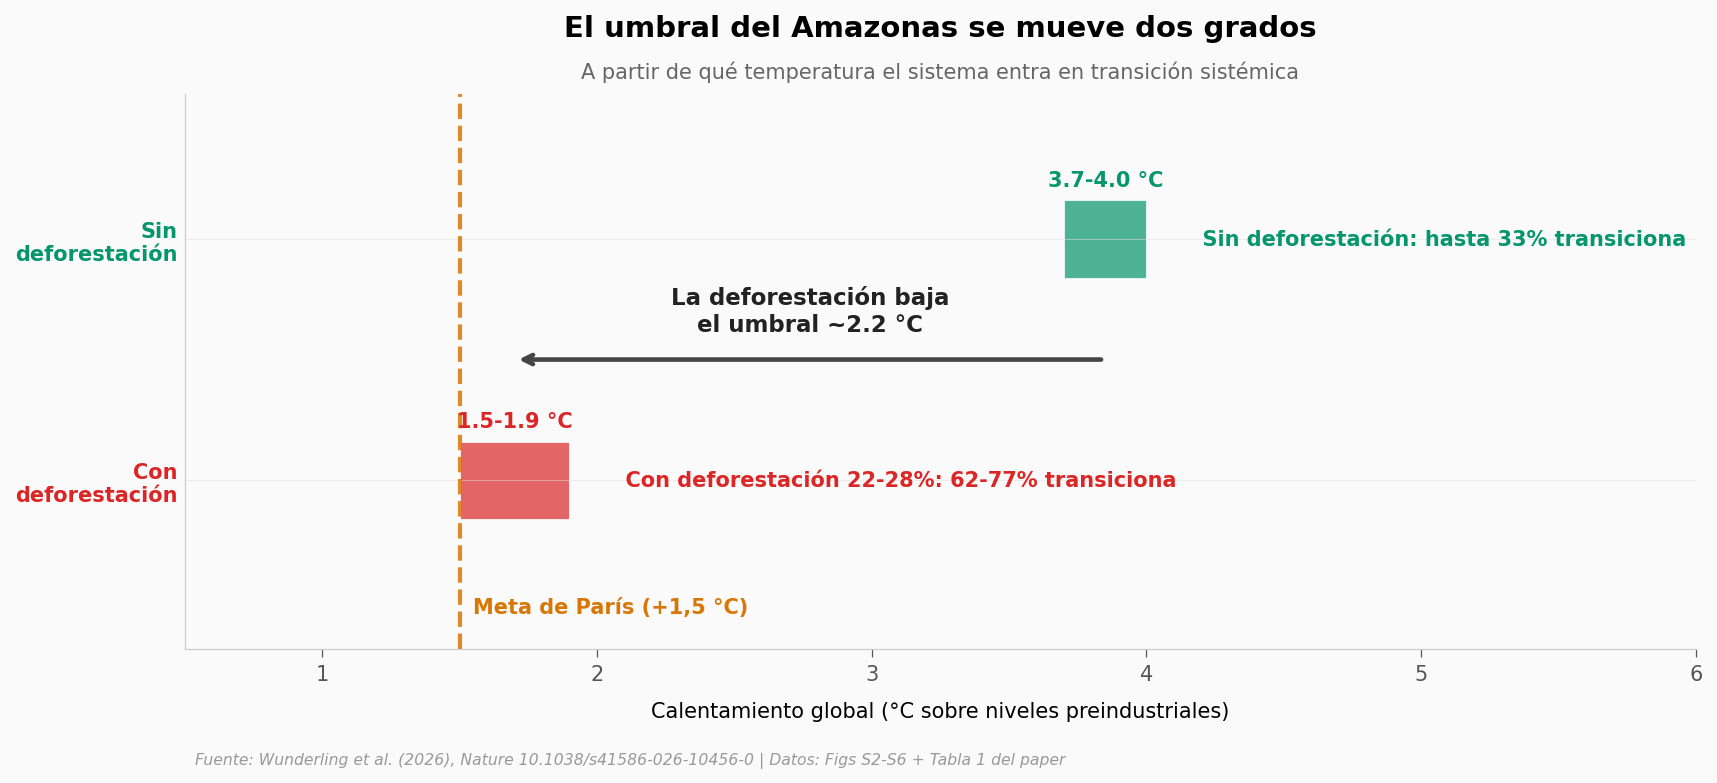

In [3]:
fig, ax = plt.subplots(figsize=(13, 4.8))

# Dos barras horizontales: rangos del umbral según escenario
y_sin = 1
y_con = 0

h = headlines
sin_min, sin_max = h.loc[h.escenario=='sin_deforestacion', ['umbral_warming_C_min','umbral_warming_C_max']].iloc[0]
con_min, con_max = h.loc[h.escenario=='con_deforestacion_BaU', ['umbral_warming_C_min','umbral_warming_C_max']].iloc[0]

ax.barh(y_sin, sin_max - sin_min, left=sin_min, height=0.32,
        color=COLOR_SIN_DEFOR, alpha=0.7, edgecolor='white')
ax.barh(y_con, con_max - con_min, left=con_min, height=0.32,
        color=COLOR_CON_DEFOR, alpha=0.7, edgecolor='white')

# Línea de París
ax.axvline(x=UMBRAL_PARIS, color=COLOR_REFERENCIA, linewidth=2,
           linestyle='--', alpha=0.85)
ax.text(UMBRAL_PARIS + 0.05, -0.55, 'Meta de París (+1,5 °C)',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold')

# Flecha mostrando el desplazamiento del umbral
media_sin = (sin_min + sin_max) / 2
media_con = (con_min + con_max) / 2
ax.annotate('', xy=(media_con, 0.5), xytext=(media_sin, 0.5),
            arrowprops=dict(arrowstyle='->', color='#444444', lw=2.2))
ax.text((media_sin + media_con) / 2, 0.62,
        f'La deforestación baja\nel umbral ~{media_sin - media_con:.1f} °C',
        fontsize=11, color='#222222', ha='center', fontweight='bold')

# Labels para cada barra (texto descriptivo a la derecha del rango)
ax.text(sin_max + 0.15, y_sin, f'  Sin deforestación: hasta 33% transiciona',
        fontsize=10, color=COLOR_SIN_DEFOR, fontweight='bold', va='center')
ax.text(con_max + 0.15, y_con, f'  Con deforestación 22-28%: 62-77% transiciona',
        fontsize=10, color=COLOR_CON_DEFOR, fontweight='bold', va='center')

# Anotación con valor del rango sobre cada barra
ax.text(media_sin, y_sin + 0.22, f'{sin_min}-{sin_max} °C',
        ha='center', fontsize=10, color=COLOR_SIN_DEFOR, fontweight='bold')
ax.text(media_con, y_con + 0.22, f'{con_min}-{con_max} °C',
        ha='center', fontsize=10, color=COLOR_CON_DEFOR, fontweight='bold')

ax.set_yticks([y_con, y_sin])
ax.set_yticklabels(['Con\ndeforestación', 'Sin\ndeforestación'],
                   fontsize=10, fontweight='bold')
ax.get_yticklabels()[0].set_color(COLOR_CON_DEFOR)
ax.get_yticklabels()[1].set_color(COLOR_SIN_DEFOR)
ax.set_xlim(0.5, 6.0)
ax.set_ylim(-0.7, 1.6)
ax.set_xlabel('Calentamiento global (°C sobre niveles preindustriales)', fontsize=10)
ax.set_title('El umbral del Amazonas se mueve dos grados',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'A partir de qué temperatura el sistema entra en transición sistémica',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_umbral_desplazado.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cómo se llega a esos números, década por década?

El umbral final es una foto de fin de siglo. Pero cuando el modelo separa los dos motores hidrológicos que lo controlan — la **lluvia anual total** (MAP) y el **déficit acumulado en la estación seca** (MCWD) — se ve que cada uno empuja en momentos distintos del recorrido.

Estas son las simulaciones del paper que aíslan cada motor por separado en SSP3-7.0 (el escenario intermedio-alto):

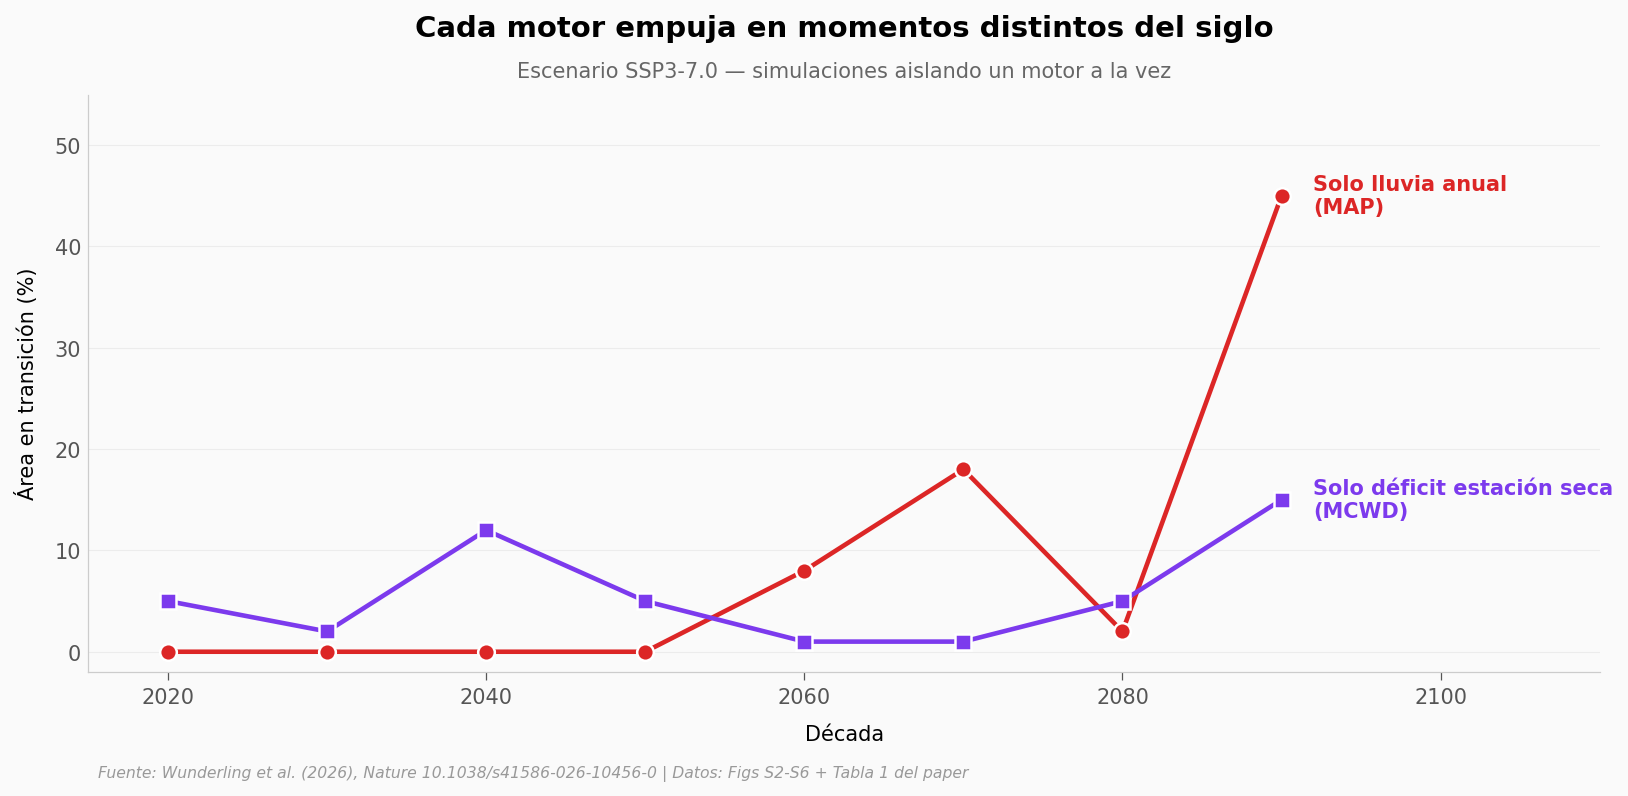

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

# Filtrar SSP3-7.0 (el escenario más informativo: muestra el cruce de motores)
map_ssp3 = decadal_map[decadal_map['ssp']=='SSP3-7.0'].sort_values('decade')
mcwd_ssp3 = decadal_mcwd[decadal_mcwd['ssp']=='SSP3-7.0'].sort_values('decade')

ax.plot(map_ssp3['decade'], map_ssp3['transitioned_pct'],
        marker='o', markersize=8, linewidth=2.2, color=COLOR_CON_DEFOR,
        markeredgecolor='white', markeredgewidth=1.2)
ax.plot(mcwd_ssp3['decade'], mcwd_ssp3['transitioned_pct'],
        marker='s', markersize=8, linewidth=2.2, color=COLOR_CONTEXTO,
        markeredgecolor='white', markeredgewidth=1.2)

# Inline labels al final de cada línea
x_last_map = map_ssp3['decade'].iloc[-1]
y_last_map = map_ssp3['transitioned_pct'].iloc[-1]
x_last_mcwd = mcwd_ssp3['decade'].iloc[-1]
y_last_mcwd = mcwd_ssp3['transitioned_pct'].iloc[-1]

ax.text(x_last_map + 2, y_last_map, 'Solo lluvia anual\n(MAP)',
        fontsize=10, color=COLOR_CON_DEFOR, fontweight='bold', va='center')
ax.text(x_last_mcwd + 2, y_last_mcwd, 'Solo déficit estación seca\n(MCWD)',
        fontsize=10, color=COLOR_CONTEXTO, fontweight='bold', va='center')

ax.set_xlabel('Década', fontsize=10)
ax.set_ylabel('Área en transición (%)', fontsize=10)
ax.set_xlim(2015, 2110)
ax.set_ylim(-2, 55)
ax.set_xticks([2020, 2040, 2060, 2080, 2100])
ax.set_title('Cada motor empuja en momentos distintos del siglo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Escenario SSP3-7.0 — simulaciones aislando un motor a la vez',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_motores_decadal.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan al filo está el sistema hidrológico?

El umbral en grados Celsius es la salida del modelo. Pero por debajo hay otro número crítico — **cuánta lluvia recibe el Amazonas y a qué distancia está del mínimo que un bosque tropical puede tolerar**. Esa es la variable que la deforestación toca directamente al cortar el reciclaje de humedad.

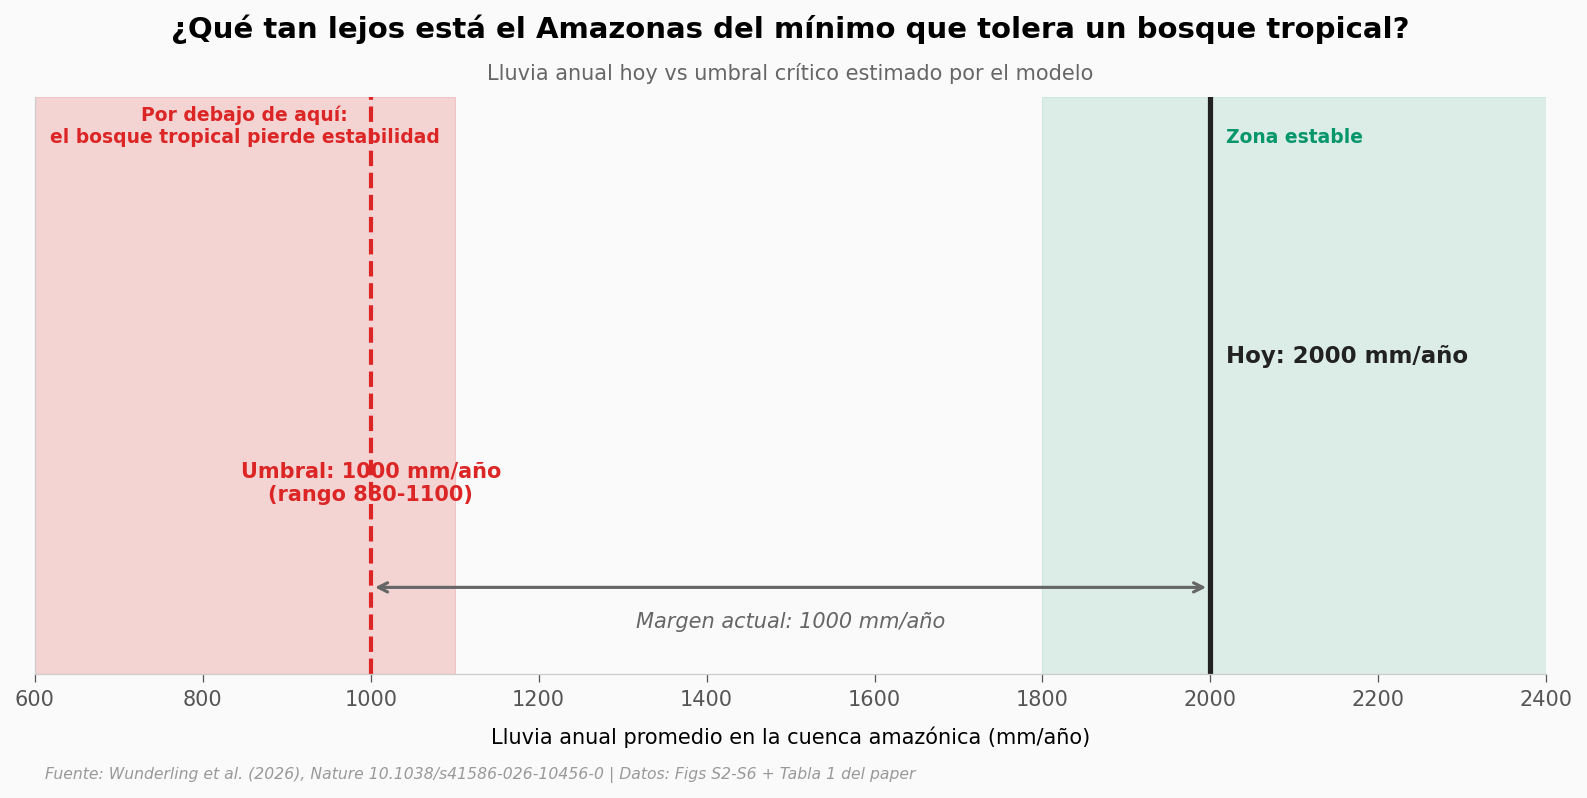

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

# Lluvia anual: actual vs límite seguro vs umbral crítico
u_map = umbrales[umbrales['variable']=='MAP'].iloc[0]
actual = u_map['promedio_basin_mm_yr']
limite = u_map['limite_seguro_mm_yr']
umbral = u_map['umbral_critico_mm_yr']
umbral_min = u_map['umbral_critico_min']
umbral_max = u_map['umbral_critico_max']

# Eje horizontal: rango de lluvia mm/yr
x_min, x_max = 600, 2400
ax.set_xlim(x_min, x_max)
ax.set_ylim(0, 1)
ax.set_yticks([])

# Banda 'umbral crítico' (zona donde el bosque no aguanta)
ax.axvspan(x_min, umbral_max, color=COLOR_CON_DEFOR, alpha=0.18)
ax.text((x_min + umbral_max)/2, 0.92, 'Por debajo de aquí:\nel bosque tropical pierde estabilidad',
        fontsize=9, color=COLOR_CON_DEFOR, ha='center', fontweight='bold')

# Banda 'zona segura'
ax.axvspan(limite, x_max, color=COLOR_SIN_DEFOR, alpha=0.12)
ax.text((limite + x_max)/2, 0.92, 'Zona estable',
        fontsize=9, color=COLOR_SIN_DEFOR, ha='center', fontweight='bold')

# Línea vertical: lluvia actual
ax.axvline(x=actual, color='#222222', linewidth=2.5)
ax.text(actual, 0.55, f'  Hoy: {int(actual)} mm/año',
        fontsize=11, color='#222222', fontweight='bold', va='center')

# Marcador del umbral central
ax.axvline(x=umbral, color=COLOR_CON_DEFOR, linewidth=2, linestyle='--')
ax.text(umbral, 0.30, f'Umbral: {int(umbral)} mm/año\n(rango {int(umbral_min)}-{int(umbral_max)})',
        fontsize=10, color=COLOR_CON_DEFOR, fontweight='bold', ha='center')

# Flecha bidireccional mostrando margen actual
ax.annotate('', xy=(umbral, 0.15), xytext=(actual, 0.15),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((actual + umbral)/2, 0.08,
        f'Margen actual: {int(actual - umbral)} mm/año',
        fontsize=10, color='#666666', ha='center', style='italic')

ax.set_xlabel('Lluvia anual promedio en la cuenca amazónica (mm/año)', fontsize=10)
ax.set_title('¿Qué tan lejos está el Amazonas del mínimo que tolera un bosque tropical?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Lluvia anual hoy vs umbral crítico estimado por el modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_margen_hidrologico.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La deforestación BaU baja el umbral crítico ~2 °C | ✅ | Sin deforestación: 3,7-4,0 °C. Con deforestación 22-28%: 1,5-1,9 °C. Diferencia entre puntos medios: 2,15 °C. (`headline_thresholds.csv`) |
| En SSP1-2.6 (+1,8 °C), la deforestación cambia el destino del Amazonas en 62 puntos porcentuales | ✅ | Sin deforestación: 0% del área transiciona; con deforestación: 62% (± 5%). (`transition_2090s_por_ssp.csv`) |
| A 4 °C la diferencia entre escenarios se reduce | ✅ | En SSP3-7.0 la brecha cae a 43 pp (35% sin vs 78% con). El sistema climático ya empuja por su cuenta. |
| Lluvia anual actual del Amazonas vs umbral crítico | ⚠️ | Hoy ~2.000 mm/año, umbral central ~1.000 mm/año (rango 880-1.100). El margen es real pero la deforestación reduce activamente la lluvia vía moisture recycling. |
| Las transiciones provienen mayormente de cascadas espaciales | ⚠️ | Es lo que el paper enmarca como hallazgo central, pero el dataset agregado del notebook no separa transiciones locales de cascadas. Verificable en Figs S11-S14 del SI. |

> **Limitaciones:**
> - Los datos del notebook son **valores reconstruidos a partir de las figuras y tabla 1 del paper** (el archivo de Figshare contiene el código del modelo, no los resultados tabulados).
> - El modelo no simula explícitamente dinámicas de fuego — la asunción de transiciones locales lo incluye implícitamente, pero faltan las interacciones drought-fire.
> - Los SSPs estándar no incluyen escenarios de deforestación severa; el paper agregó un escenario BaU adicional siguiendo Soares-Filho et al. (2013).
> - Resultados son **proyecciones de modelo, no observaciones**. El reciclaje de humedad (moisture recycling) validado contra ERA5 (el reanálisis climático estándar) muestra un sesgo de +5,5% (R² = 0,59).
> - El modelo se basa en NorESM2 (un modelo climático global noruego, parte del set CMIP6); otros modelos climáticos podrían arrojar umbrales distintos.

## Ahora tú

1. **¿Qué pasa si la deforestación se quedara congelada en el nivel actual (≈20%) en lugar de subir a BaU?** El paper trae el escenario en `ssp_defor_2090.csv` — comparar la columna `transitioned_con_defor_pct` allí (deforestación moderada) con la de `transition_2090s_por_ssp.csv` (BaU) por SSP.
2. **¿Cuál motor hidrológico — MAP o MCWD — explica más transición acumulada al fin de siglo?** Sumar `transitioned_pct` por motor en los archivos `decadal_map_only.csv` y `decadal_mcwd_only.csv`.
3. **¿Qué tan separados están los rangos del umbral con vs sin deforestación?** Calcular la mínima distancia entre los dos intervalos. Si no se traslapan, el efecto de la deforestación es estadísticamente claro incluso en los bordes.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Cuánto cambia el destino del Amazonas si la deforestación se queda en el nivel actual
# (~20-25%) en vez de seguir hasta BaU?

comparacion = pd.merge(
    ssp[['ssp', 'warming_2090s_C', 'transitioned_pct_con_deforestacion']].rename(
        columns={'transitioned_pct_con_deforestacion': 'BaU'}),
    ssp_defor[['ssp', 'transitioned_con_defor_pct']].rename(
        columns={'transitioned_con_defor_pct': 'moderada'}),
    on='ssp')

comparacion['diferencia_pp'] = comparacion['BaU'] - comparacion['moderada']
print('Área en transición a fin de siglo (%) — deforestación moderada vs BaU')
print(comparacion.to_string(index=False))
print()
print(f'Reducción promedio si se contiene la deforestación: '
      f'{comparacion["diferencia_pp"].mean():.1f} puntos porcentuales')

Área en transición a fin de siglo (%) — deforestación moderada vs BaU
     ssp  warming_2090s_C  BaU  moderada  diferencia_pp
SSP1-2.6              1.8   62        10             52
SSP2-4.5              2.8   61        16             45
SSP3-7.0              4.0   78        46             32
SSP5-8.5              4.9   75        33             42

Reducción promedio si se contiene la deforestación: 42.8 puntos porcentuales


## Fuentes

**Paper**: [Deforestation-induced drying lowers Amazon climate threshold](https://doi.org/10.1038/s41586-026-10456-0)  
*Nature, 2026-05-06*

**Supplementary Material**: [Figs S1–S14 con valores numéricos por SSP, década y umbral](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10456-0/MediaObjects/41586_2026_10456_MOESM1_ESM.pdf)  
*Nature (Supplementary Information), 2026-05-06*

**Dataset canónico**: [Code to the manuscript 'Deforestation-induced drying lowers amazon climate threshold'](https://doi.org/10.6084/m9.figshare.28191128)  
*Figshare — código PyCascades + escenarios SSP land-use*

**Referencias citadas**: [ORNL DAAC](https://doi.org/10.3334/ORNLDAAC/1153)

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — todos los notebooks reproducibles del canal.  
**Licencia:** MIT (código) · CC-BY 4.0 (texto y figuras)